<a href="https://colab.research.google.com/github/elzbietapiechota/neural-network-dense/blob/main/NN_Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.7785 - loss: 0.6158 - val_accuracy: 0.8511 - val_loss: 0.4048
Epoch 2/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.8438 - loss: 0.4346 - val_accuracy: 0.8604 - val_loss: 0.3732
Epoch 3/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8569 - loss: 0.3921 - val_accuracy: 0.8711 - val_loss: 0.3398
Epoch 4/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8693 - loss: 0.3634 - val_accuracy: 0.8811 - val_loss: 0.3199
Epoch 5/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8736 - loss: 0.3456 - val_accuracy: 0.8759 - val_loss: 0.3289
Epoch 6/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8803 - loss: 0.3271 - val_accuracy: 0.8881 - val_loss: 0.2972
Epoch 7/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8847 - loss: 0.3165 - val_accuracy: 0.8893 - val_loss: 0.2970
Epoch 8/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8892 - loss: 0.3020 - val_a

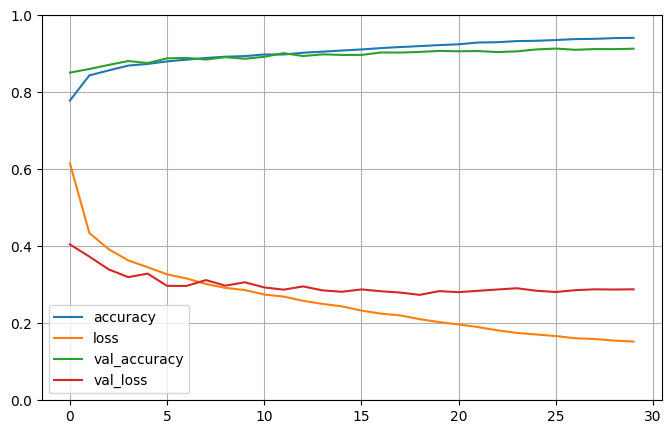

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
probs :  [5.7672773e-17 1.3546789e-18 5.4590389e-16 2.0016886e-18 4.5070071e-17
 6.9716988e-10 2.3802410e-17 1.0000000e+00 1.3145781e-11 8.0940249e-10]
klasa : 7
rzeczywista klasa:  7


In [ ]:
import numpy as np
import tensorflow as tf
from keras import layers
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

# załadowanie zbioru Fashion MNIST
train, test = tf.keras.datasets.fashion_mnist.load_data()

# wydobycie obrazów oraz labelek
images, labels = train

# normalizacja wartości pikseli
images = images/255.0

# zapis danych jako int
labels = labels.astype(np.int32)

# podział zbioru na treningowy, walidacyjny i testowy
X_train_full, X_test, y_train_full, y_test = \
    train_test_split(images, labels, test_size=0.1, random_state=10, stratify=labels)

X_train, X_val, y_train, y_val = \
    train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=10, stratify=y_train_full)

# stworzenie zbioru typu Dataset z listy
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# ustawienie batch_size na 128 oraz przetasowanie na bazie 1000 próbek
train_ds = train_ds.shuffle(1000).batch(128).prefetch(tf.data.AUTOTUNE)

# budowa modelu
f_mnist_model = tf.keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax')
])

# podsumowanie budowy modelu
f_mnist_model.summary()

# scheduler cosine z rozgrzewką
total_epochs = 30
steps_per_epoch = len(train_ds)
total_train_steps = total_epochs * steps_per_epoch

# rozgrzewka
warmup_epochs = 3
warmup_steps = warmup_epochs * steps_per_epoch

# scheduler cosine
cosine_warmup_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=total_train_steps,
    warmup_target=1e-3,
    warmup_steps=warmup_steps,
    alpha=1e-5
)

# kompilacja modelu
f_mnist_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_warmup_schedule),
    metrics=['accuracy'],
    jit_compile=True
)

# trening modelu
train_stats = f_mnist_model.fit(
    train_ds,
    epochs=total_epochs,
    validation_data=(X_val, y_val),
    verbose=1
)

# wizualizacja wyniku
pd.DataFrame(train_stats.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

y_pred = f_mnist_model.predict(X_test)
print("probs : ", y_pred[2])
print("klasa :", np.argmax(y_pred[2]))
print("rzeczywista klasa: ", y_test[2])

In [ ]:
# dokładność modelu na zbiorze testowym
test_loss, test_acc = f_mnist_model.evaluate(X_test, y_test, verbose=0)
print(f"Ogólna dokładność na zbiorze testowym: {test_acc:.4f}")

Ogólna dokładność na zbiorze testowym: 0.9055


In [ ]:
# zapis modelu
f_mnist_model.save('model_fashion_mnist.keras')

In [ ]:
# załadowanie modelu
aug_f_mnist_model = tf.keras.models.load_model('model_fashion_mnist.keras')

In [ ]:
# wizualizacja działania modelu na podstawie próbki
def image_verification(index, X_test, y_test, model):
    class_names = ['T-shirt', 'Spodnie', 'Sweter', 'Sukienka', 'Płaszcz',
                   'Sandał', 'Koszula', 'But sportowy', 'Torba', 'Botek']

    # pobranie próbki i ustalenie wymiaru paczki
    img = X_test[index]
    img_batch = np.expand_dims(img, axis=0)

    # predykcja klasy
    pred_probs = model.predict(img_batch, verbose=0)
    class_pred = np.argmax(pred_probs)
    class_real = y_test[index]

    # podanie próbki
    plt.figure(figsize=(3, 3))
    plt.imshow(img, cmap='gray')
    plt.axis('off')

    plt.title(f"Model: {class_names[class_pred]}\nRzeczywistość: {class_names[class_real]}")
    plt.show()

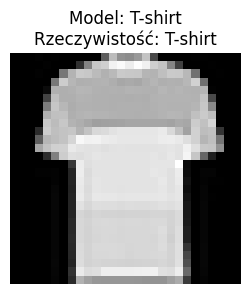

In [ ]:
# Sprawdzenie działania modelu
image_verification(101, X_test, y_test, f_mnist_model)

In [ ]:
import numpy as np
import tensorflow as tf
from keras import layers
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
import cv2

# załadowanie zbioru Fashion MNIST
train, test = tf.keras.datasets.fashion_mnist.load_data()

# wydobycie obrazów oraz labelek
images, labels = train

# normalizacja wartości pikseli
images = images/255.0

# zapis danych jako int
labels = labels.astype(np.int32)

# podział zbioru na treningowy, walidacyjny i testowy
X_train_full, X_test, y_train_full, y_test = \
    train_test_split(images, labels, test_size=0.1, random_state=10, stratify=labels)

X_train, X_val, y_train, y_val = \
    train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=10, stratify=y_train_full)

# augmentacja zbioru danych
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(
        translate_percent={"x": (-0.04, 0.04), "y": (-0.04, 0.04)},
        scale=(0.98, 1.02),
        rotate=(-4, 4),
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        p=0.7
    )
])

X_aug_version_A = []
X_aug_version_B = []

for img in X_train:
    aug_A = transform(image=img)
    X_aug_version_A.append(aug_A['image'])

    aug_B = transform(image=img)
    X_aug_version_B.append(aug_B['image'])

X_aug_version_A = np.array(X_aug_version_A, dtype=np.float32)
X_aug_version_B = np.array(X_aug_version_B, dtype=np.float32)

y_aug_version_A = y_train.copy()
y_aug_version_B = y_train.copy()

X_train = np.concatenate((X_train, X_aug_version_A, X_aug_version_B), axis=0)
y_train = np.concatenate((y_train, y_aug_version_A, y_aug_version_B), axis=0)

# stworzenie zbioru typu Dataset z listy
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# ustawienie batch_size na 64 oraz przetasowanie na bazie 10000 próbek
train_ds = train_ds.shuffle(10000).batch(128).prefetch(tf.data.AUTOTUNE)

# budowa modelu
aug_f_mnist_model = tf.keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

# scheduler cosinus z rozgrzewką
total_epochs = 30
steps_per_epoch = len(train_ds)
total_train_steps = total_epochs * steps_per_epoch
warmup_steps = 3 * steps_per_epoch

cosine_warmup_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=total_train_steps,
    warmup_target=1e-3,
    warmup_steps=warmup_steps,
    alpha=1e-5
)

# kompilacja modelu
aug_f_mnist_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_warmup_schedule),
    metrics=['accuracy'],
    jit_compile=True
)

# trening modelu
train_stats = aug_f_mnist_model.fit(
    train_ds,
    epochs=total_epochs,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/30
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.8085 - loss: 0.5273 - val_accuracy: 0.8654 - val_loss: 0.3748
Epoch 2/30
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.8562 - loss: 0.3943 - val_accuracy: 0.8822 - val_loss: 0.3212
Epoch 3/30
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.8687 - loss: 0.3590 - val_accuracy: 0.8854 - val_loss: 0.3125
Epoch 4/30
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.8769 - loss: 0.3362 - val_accuracy: 0.8854 - val_loss: 0.3103
Epoch 5/30
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.8822 - loss: 0.3181 - val_accuracy: 0.8889 - val_loss: 0.2948
Epoch 6/30
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.8878 - loss: 0.3040 - val_accuracy: 0.8878 - val_loss: 0.3112
Epoch 7/30
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.8907 - loss: 0.2942 - val_accuracy: 0.8954 - val_loss: 0.2813
Epoch 8/30
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.8946 -

In [ ]:
test_loss, test_acc = aug_f_mnist_model.evaluate(X_test, y_test, verbose=0)
print(f"Ogólna dokładność na zbiorze testowym: {test_acc:.4f}")

Ogólna dokładność na zbiorze testowym: 0.9102


In [ ]:
aug_f_mnist_model.save('aug_model_fashion_mnist.keras')